# SSD MobileNet V2 FPNLite (320×320) — PhenoBench (tiled) PTQ (ptq)

Post-training-quantization **base**: a plain float finetune (**no QAT**) for
**multi-class crop-vs-weed instance detection** on the *tiled* PhenoBench dataset,
resuming from the companion *finetune* notebook's export
and re-training under the SAME softened augmentation and reduced LR/steps as the
QAT notebooks, so the PTQ and QAT models start from comparable training regimes.
The resulting float checkpoint is what `tflite_conversion.py` calibrates to int8
(per-tensor or per-channel -- a converter flag).

## Inputs

- **Finetune output** — attach this config's finetune notebook output via
  *Add Input → Your Work / Notebook Output*. Kaggle mounts it at
  `/kaggle/input/notebooks/freimutdiener/ssd-mn2-fpnlite-mc-phenobench-tiled-320-finetune`; its `finetune/` (zoo layout: `checkpoint/` +
  `pipeline.config`) is the resume base.
- The PhenoBench dataset bundle (`train.record` / `val.record` / `label_map`).

## Output contract (`/kaggle/working`)

On completion the working directory holds exactly:

```
/kaggle/working/
├── manifest.ptq.json    # fragment manifest: only the `ptq` stage
└── ptq/
    ├── checkpoint/          # float model-only ckpt-0
    ├── saved_model/         # SavedModel (fp32)
    ├── graphs/              # training / validation curves (PDF)
    ├── pipeline.config      # as-run TFOD pipeline
    ├── best_metric.json
    └── metrics_history.json
```

The fragment is merged into the finetune's `manifest.json` after the fact
(see `scripts/sync_kaggle_runs.py`).

## 1 · Environment

Target runtime (Kaggle, "Pin to original environment" enabled):

- Python 3.10 · TensorFlow 2.11 · CUDA-enabled GPU

> **Kaggle inputs:** attach the **`ssd-mobilenet-v2-fpnlite-320x320-coco17-tpu-8`** model and the `mc-phenobench` / PhenoBench raw datasets as notebook inputs before running.

In [1]:
!python -V

Python 3.10.10


In [2]:
!pip install --no-cache-dir --no-deps \
  tf_slim \
  pycocotools \
  lvis \
  contextlib2 \
  gin-config \
  tf-models-official==2.13.2 \
  tensorflow-model-optimization==0.7.5 \
  git+https://github.com/frdiener/agri-vision-edge.git

  Cloning https://github.com/frdiener/agri-vision-edge.git to /tmp/pip-req-build-hyjsads0
  Running command git clone --filter=blob:none --quiet https://github.com/frdiener/agri-vision-edge.git /tmp/pip-req-build-hyjsads0
  Resolved https://github.com/frdiener/agri-vision-edge.git to commit 08e713386a41cb1a10ff0471543e086420940305
  Installing build dependencies ... - \ | / done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.1/352.1 kB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.5/472.5 kB 81.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 290.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 183.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 241.2/241.2 kB 326.2 MB/s eta 0:00:00
  Created wheel for agri-vision-edge: filename=agri_vision_edge-0.1.0-py3-none-any.whl size=1879695 sha2

In [3]:
import json
import shutil
from pathlib import Path
from dataclasses import asdict
import matplotlib.pyplot as plt

# setup_tensorflow_models() must run before anything imports object_detection.
from agri_vision_edge.third_party import setup_tensorflow_models
setup_tensorflow_models()

from agri_vision_edge.experiment import (
    ExperimentManifest,
    capture_environment,
)
from agri_vision_edge.experiment import (
    AugmentationConfig,
    FineTuneConfig,
)

# The shared trainer: one config object drives finetune / QAT + export.
from agri_vision_edge.tfod_trainer import (
    FinetuneRunConfig,
    run_finetune,
    write_pipeline,
    export_run,
)

# Curves are read back from the trainer's metrics_history.json (no TensorBoard).
from agri_vision_edge.evaluation.curves import (
    load_history_scalars,
    available_tags,
    plot_metric_curves,
    plot_loss_curves,
    plot_learning_rate,
    plot_steps_per_second,
    plot_map_curves,
    plot_recall_curves,
)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2 · Output paths

`tfod_trainer` writes its working tree into a `/tmp` scratch dir; the published
`/kaggle/working` holds only the `manifest.ptq.json` fragment and the assembled
`ptq/` artifact.

In [4]:
WORK = Path("/kaggle/working")

LABEL = "ptq"

PTQ_DIR = WORK / LABEL
GRAPHS_PATH = PTQ_DIR / "graphs"
MANIFEST_PATH = WORK / "manifest.ptq.json"

# Finetune export consumed as the resume base (model_path).
FINETUNE_DIR = Path("/kaggle/input/notebooks/freimutdiener/ssd-mn2-fpnlite-mc-phenobench-tiled-320-finetune")
FINETUNE_BASE = FINETUNE_DIR / "finetune"

# Intermediate scratch (kept off /kaggle/working so it is never published).
RUN_DIR = Path("/tmp/ave_ptq_run")

GRAPHS_PATH.mkdir(parents=True, exist_ok=True)
assert FINETUNE_BASE.exists(), (
    f"Finetune export not found at {FINETUNE_BASE} -- attach this config's "
    "finetune notebook output as an input."
)

## 3 · Experiment manifest (fragment)

A **fragment** manifest carrying only this PTQ stage, merged into the finetune's
full `manifest.json` later. The run's environment is recorded inside the stage
`runtime` so it survives the merge.

In [5]:
manifest = ExperimentManifest(
    name="ssd-mobilenet-v2-fpnlite_mc_phenobench-tiled_320x320",
    task="object_detection",
)

env = capture_environment()
manifest.set_environment(platform="kaggle", **env)

## 4 · PTQ configuration

The pipeline tuning (anchors, matcher thresholds, base augmentation, NMS) is
**inherited from the finetune's manifest** (`stages.finetune.config`). Only the
reduced-schedule knobs are overridden -- identical to the QAT notebooks so the
PTQ base and the QAT models are trained under the same regime:

- **Optimization** softened — low learning rate and a short schedule from the
  converged fp32 weights.
- **Augmentation** softened — photometric jitter and random crop/zoom dropped,
  keeping only the geometric (flip / 90° rotation) symmetries.
- **No QAT** — plain float training; int8 granularity is chosen at conversion.

In [6]:
from dataclasses import fields

# Inherit the finetune's pipeline tuning (anchors, matcher thresholds, base
# augmentation, NMS) from its manifest, so the anchor semantics the head was
# trained against are preserved exactly. Only the QAT knobs are overridden.
stage_config = (
    ExperimentManifest.load(FINETUNE_DIR / "manifest.json")
    .data["stages"]["finetune"]["config"]
)
# Accept both the whole-run mapping (new: a FinetuneRunConfig.to_mapping() with a
# nested "finetune") and the legacy flat FineTuneConfig dict.
finetune_config = dict(stage_config.get("finetune", stage_config))

# Soften augmentation for QAT: drop photometric jitter and random crop/zoom,
# keep the geometric (flip / 90-degree rotation) symmetries.
augmentation = AugmentationConfig(**finetune_config.pop("augmentation"))
augmentation.random_crop = False
augmentation.zoom_range = None
augmentation.brightness_max_delta = None
augmentation.contrast_range = None
augmentation.saturation_range = None
augmentation.jpeg_quality_range = None

# Keep only FineTuneConfig fields (drops any legacy early_stopping / control keys
# that older manifests stored alongside the pipeline tuning).
_ft_fields = {f.name for f in fields(FineTuneConfig)} - {"augmentation"}
finetune_config = {k: v for k, v in finetune_config.items() if k in _ft_fields}

config = FineTuneConfig(**finetune_config, augmentation=augmentation)

# The stage's full config (the whole FinetuneRunConfig mapping) is committed
# below, once the run config is assembled.
manifest.add_stage(LABEL, runtime={"environment": env})

"defined"

'defined'

## 5 · Dataset

A `tfod_trainer` *dataset bundle* is a directory holding `label_map.pbtxt`,
`train.record` and `val.record` — exactly the layout of the mounted
`mc-phenobench` dataset. The raw PhenoBench images are used only for
qualitative evaluation at the end.

In [7]:
manifest.set_dataset(
    name="phenobench-tiled",
    train_split="train",
    validation_split="val",
    num_classes=2,
)

dataset_dir = Path("/kaggle/input/datasets/freimutdiener/mc-phenobench-tiled-no-partials")
dataset_raw_dir = Path("/kaggle/input/datasets/freimutdiener/phenobench-raw-dataset-v1-1-0/PhenoBench")

label_map_path = dataset_dir / "label_map.pbtxt"
test_imgs = list((dataset_raw_dir / "test" / "images").glob("*.png"))

print(f"{len(test_imgs)} test images loaded")

693 test images loaded


## 6 · Starting point and run configuration

The `model_path` is the finetune's export — a drop-in zoo-layout base model
(`checkpoint/ckpt-0.*` + `pipeline.config`). `run_finetune` resumes from it and
re-trains (float, no fake-quant) under the reduced schedule above.

In [8]:
manifest.set_checkpoint(
    model_name="ssd_mobilenet_v2_fpnlite_320x320_coco17_tpu-8",
    pretrained_dataset="phenobench-tiled (finetune)",
    source="finetune_export",
)

# The finetune export, in TF model-zoo layout, is the resume base.
MODEL_DIR = FINETUNE_BASE

In [9]:
from agri_vision_edge.tfod_trainer import TrainingControlConfig

run_config = FinetuneRunConfig(
    model_path=MODEL_DIR,
    dataset_bundle_path=dataset_dir,
    num_classes=2,
    output_dir=RUN_DIR,      # scratch; the published artifact is assembled into QAT_DIR
    finetune=config,
    control=TrainingControlConfig(
        # Plain float finetune (qat=False): the PTQ base. int8 per-tensor vs
        # per-channel is chosen later by the converter, so one PTQ notebook suffices.
        qat=False,
        # Eval + checkpoint the restored finetune weights before the first step,
        # seeding the best-metric tracker with that baseline. Guarantees the PTQ
        # export is never worse than the finetune baseline even if the reduced"
        # schedule only ever regresses.
        initial_eval_checkpoint=True,
        # Treat PhenoBench partial (border / low-visibility) plants as
        # do-not-care during the continuous eval (matches `ave evaluate
        # --ignore-partials`). No-op on bundles built without partial flags.
        eval_ignore_partials=True,

        # QAT optimization schedule -- low LR, short run from converged fp32 weights.
        warmup_epochs=1,
        lr_plateau=True,
        lr_plateau_base_lr=2e-4,
        lr_plateau_warmup_lr=1e-4,
        lr_plateau_factor=0.5,
        lr_plateau_patience=6,
        lr_plateau_cooldown=1,
        lr_plateau_min_lr=5e-5,
        lr_plateau_min_delta=1e-3,
        lr_plateau_restore_best=True,
        lr_plateau_exhausted_patience=1,
    ),
    # We resume OUR OWN finetune export (matching num_classes), so restore the
    # box/class heads too (fine_tune_checkpoint_type="full") and reset the
    # optimizer/LR schedule -- exactly like QAT, just without fake-quant. Without
    # this the heads are dropped ("detection" restore) and PTQ retrains from cold
    # (near-zero AP, stuck loss).
    resume_full=True,
)

# Commit the whole run config (orchestration + finetune + control) to the stage,
# so it round-trips through FinetuneRunConfig.from_mapping.
manifest.update_stage(LABEL, config=run_config.to_mapping())

## 7 · Training

`run_finetune` builds the detection model, restores the COCO checkpoint, and
runs the training loop with metric-based checkpointing and early stopping,
appending one record per logged step to `metrics_history.json` and saving the
best checkpoint (by validation mAP) under the scratch run directory.

In [10]:
result = run_finetune(run_config)

Setting warmup steps to 792 (warmup_epochs=1 * steps_per_epoch=792).
Setting learning_rate_base to 0.0002.
Setting warmup_learning_rate to 0.0001.
Loading fine-tune checkpoint (full): /kaggle/input/notebooks/freimutdiener/ssd-mn2-fpnlite-mc-phenobench-tiled-320-finetune/finetune/checkpoint/ckpt-0


/opt/conda/lib/python3.10/site-packages/keras/backend.py:451: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


Initialized optimizer checkpoint state: 233 optimizer/EMA variable(s) for 232 trainable model variable(s).

Evaluating initial weights to seed the best-metric baseline...
creating index...
index created!
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.78s).
Accumulating evaluation results...
DONE (t=2.64s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.471
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.795
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.481
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.282
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.517
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.578
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.268
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ]

In [11]:
# Promote the metric files from the scratch run dir into the ptq artifact.
shutil.copy2(result.best_metric_path, PTQ_DIR / "best_metric.json")
shutil.copy2(result.history_path, PTQ_DIR / "metrics_history.json")

best = json.loads((PTQ_DIR / "best_metric.json").read_text())
print(
    f"Best {best['metric_name']}: {best['metric_value']:.5f} "
    f"at step {best['step']}"
)

manifest.update_stage("ptq", metrics={"best_metric": best})
manifest.update_stage(
    "ptq",
    artifacts={
        "best_metric_json": "ptq/best_metric.json",
        "metrics_history_json": "ptq/metrics_history.json",
    },
)

Best DetectionBoxes_Precision/mAP: 0.47063 at step 0


## 8 · Training and validation curves

Curves read back from `ptq/metrics_history.json`; each figure is saved into
`ptq/graphs/` as a vector PDF.

In [12]:
history_df = load_history_scalars(PTQ_DIR / "metrics_history.json")

print("Available metric tags:")
for tag in available_tags(history_df):
    print("-", tag)

Available metric tags:
- DetectionBoxes_Precision/mAP
- DetectionBoxes_Precision/mAP (large)
- DetectionBoxes_Precision/mAP (medium)
- DetectionBoxes_Precision/mAP (small)
- DetectionBoxes_Precision/mAP@.50IOU
- DetectionBoxes_Precision/mAP@.75IOU
- DetectionBoxes_Recall/AR@1
- DetectionBoxes_Recall/AR@10
- DetectionBoxes_Recall/AR@100
- DetectionBoxes_Recall/AR@100 (large)
- DetectionBoxes_Recall/AR@100 (medium)
- DetectionBoxes_Recall/AR@100 (small)
- Loss/classification_loss
- Loss/localization_loss
- Loss/regularization_loss
- Loss/total_loss
- epoch
- learning_rate
- steps_per_sec


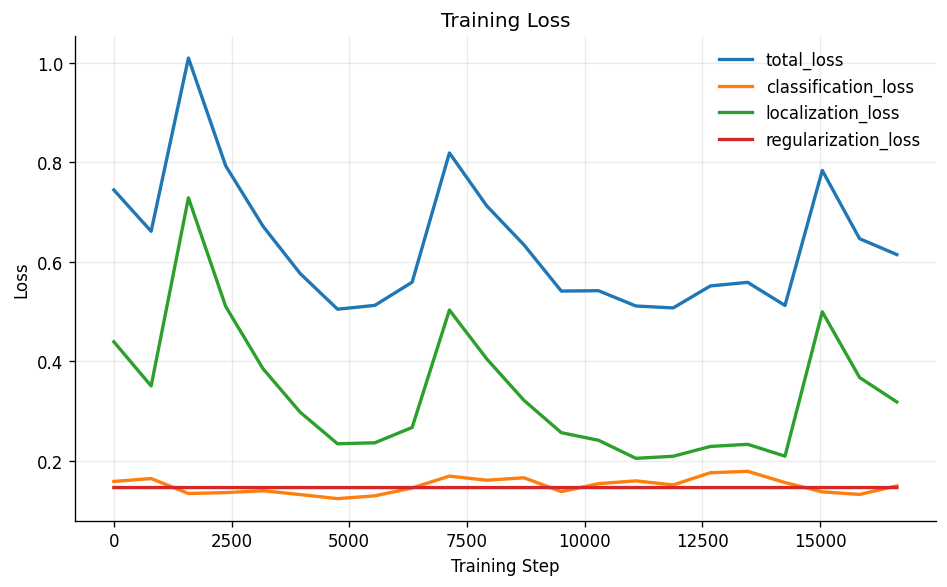

In [13]:
loss_fig, _ = plot_loss_curves(
    history_df,
    save_path=GRAPHS_PATH / "training_loss_curves.pdf",
)
display(loss_fig)

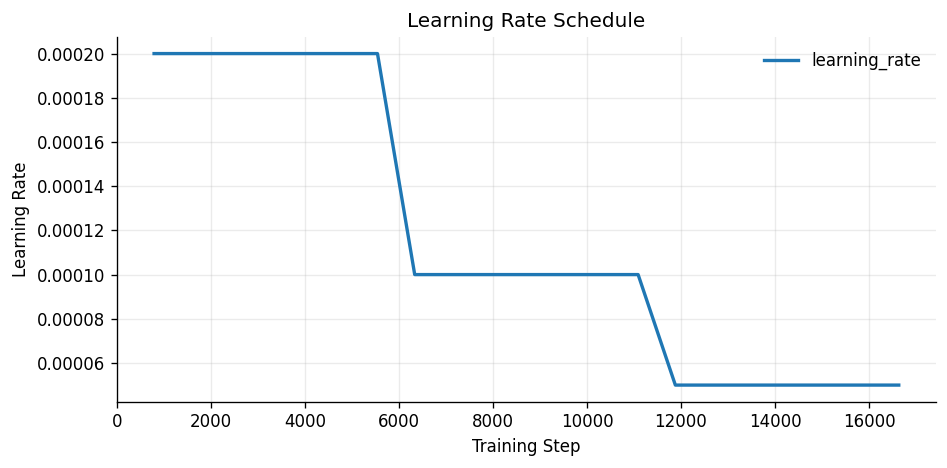

In [14]:
lr_fig, _ = plot_learning_rate(
    history_df,
    save_path=GRAPHS_PATH / "learning_rate_schedule.pdf",
)
display(lr_fig)

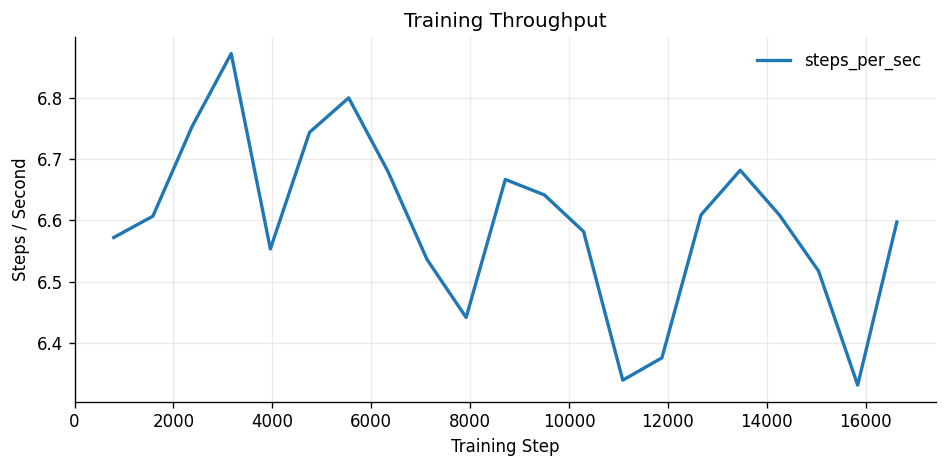

In [15]:
tput_fig, _ = plot_steps_per_second(
    history_df,
    save_path=GRAPHS_PATH / "training_throughput.pdf",
)
display(tput_fig)

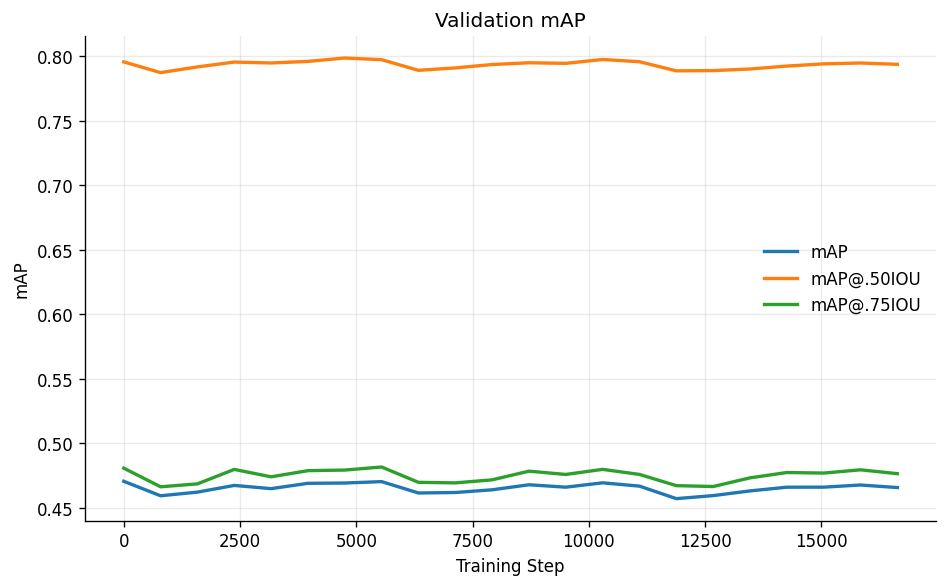

In [16]:
map_fig, _ = plot_map_curves(
    history_df,
    save_path=GRAPHS_PATH / "eval_precision_curves.pdf",
)
display(map_fig)

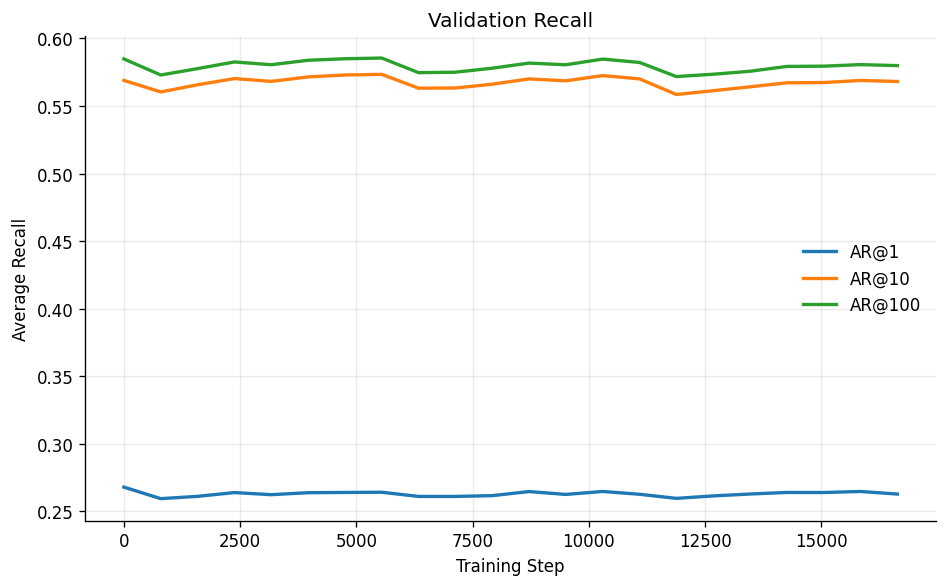

In [17]:
recall_fig, _ = plot_recall_curves(
    history_df,
    save_path=GRAPHS_PATH / "eval_recall_curves.pdf",
)
display(recall_fig)

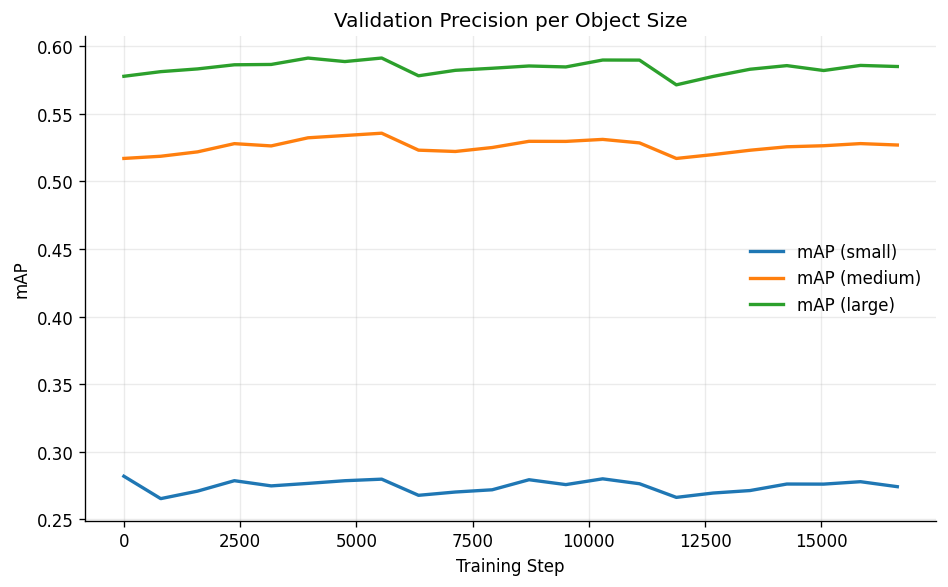

In [18]:
size_precision_fig, _ = plot_metric_curves(
    df=history_df,
    tags=[
        "DetectionBoxes_Precision/mAP (small)",
        "DetectionBoxes_Precision/mAP (medium)",
        "DetectionBoxes_Precision/mAP (large)",
    ],
    title="Validation Precision per Object Size",
    ylabel="mAP",
    save_path=GRAPHS_PATH / "eval_precision_size_curves.pdf",
)
display(size_precision_fig)

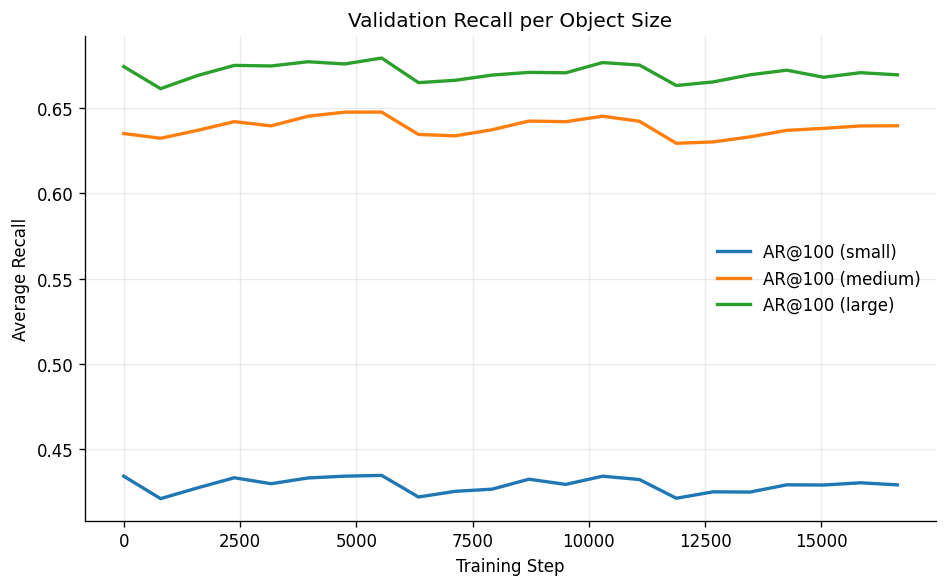

In [19]:
size_recall_fig, _ = plot_metric_curves(
    df=history_df,
    tags=[
        "DetectionBoxes_Recall/AR@100 (small)",
        "DetectionBoxes_Recall/AR@100 (medium)",
        "DetectionBoxes_Recall/AR@100 (large)",
    ],
    title="Validation Recall per Object Size",
    ylabel="Average Recall",
    save_path=GRAPHS_PATH / "eval_recall_size_curves.pdf",
)
display(size_recall_fig)

## 9 · Export

`export_run` (with `qat=False`) writes the best float checkpoint to the zoo
layout directly into `ptq/`.

In [20]:
export_result = export_run(run_config, export_dir=PTQ_DIR)

print("ptq dir:   ", export_result.export_dir)
print("SavedModel:", export_result.saved_model_dir)
print("Checkpoint:", export_result.checkpoint)
print("Pipeline:  ", export_result.pipeline_config)

ptq dir:    /kaggle/working/ptq
SavedModel: /kaggle/working/ptq/saved_model
Checkpoint: /kaggle/working/ptq/checkpoint/ckpt-0
Pipeline:   /kaggle/working/ptq/pipeline.config


## 10 · Register artifacts and publish

In [21]:
manifest.add_artifact("ptq/pipeline.config", artifact_type="pipeline_config", stage="ptq")
manifest.add_artifact("ptq/graphs", artifact_type="evaluation_plots", stage="ptq")
manifest.add_artifact("ptq/saved_model", artifact_type="tfod_saved_model", stage="ptq")
manifest.add_artifact("ptq/checkpoint", artifact_type="tfod_checkpoint", stage="ptq")

manifest.save(MANIFEST_PATH)

# Drop the scratch run dir so /kaggle/working == {manifest.ptq.json, ptq/}.
shutil.rmtree(RUN_DIR, ignore_errors=True)

print("Published:")
for p in sorted(WORK.rglob("*")):
    if p.is_file():
        print(" ", p.relative_to(WORK))

Published:
  __notebook__.ipynb
  manifest.ptq.json
  ptq/best_metric.json
  ptq/checkpoint/checkpoint
  ptq/checkpoint/ckpt-0.data-00000-of-00001
  ptq/checkpoint/ckpt-0.index
  ptq/graphs/eval_precision_curves.pdf
  ptq/graphs/eval_precision_size_curves.pdf
  ptq/graphs/eval_recall_curves.pdf
  ptq/graphs/eval_recall_size_curves.pdf
  ptq/graphs/learning_rate_schedule.pdf
  ptq/graphs/training_loss_curves.pdf
  ptq/graphs/training_throughput.pdf
  ptq/metrics_history.json
  ptq/pipeline.config
  ptq/saved_model/fingerprint.pb
  ptq/saved_model/saved_model.pb
  ptq/saved_model/variables/variables.data-00000-of-00001
  ptq/saved_model/variables/variables.index


## 11 · Qualitative evaluation

Predictions on unseen PhenoBench test images, using the exported fp32 SavedModel
from `ptq/`.

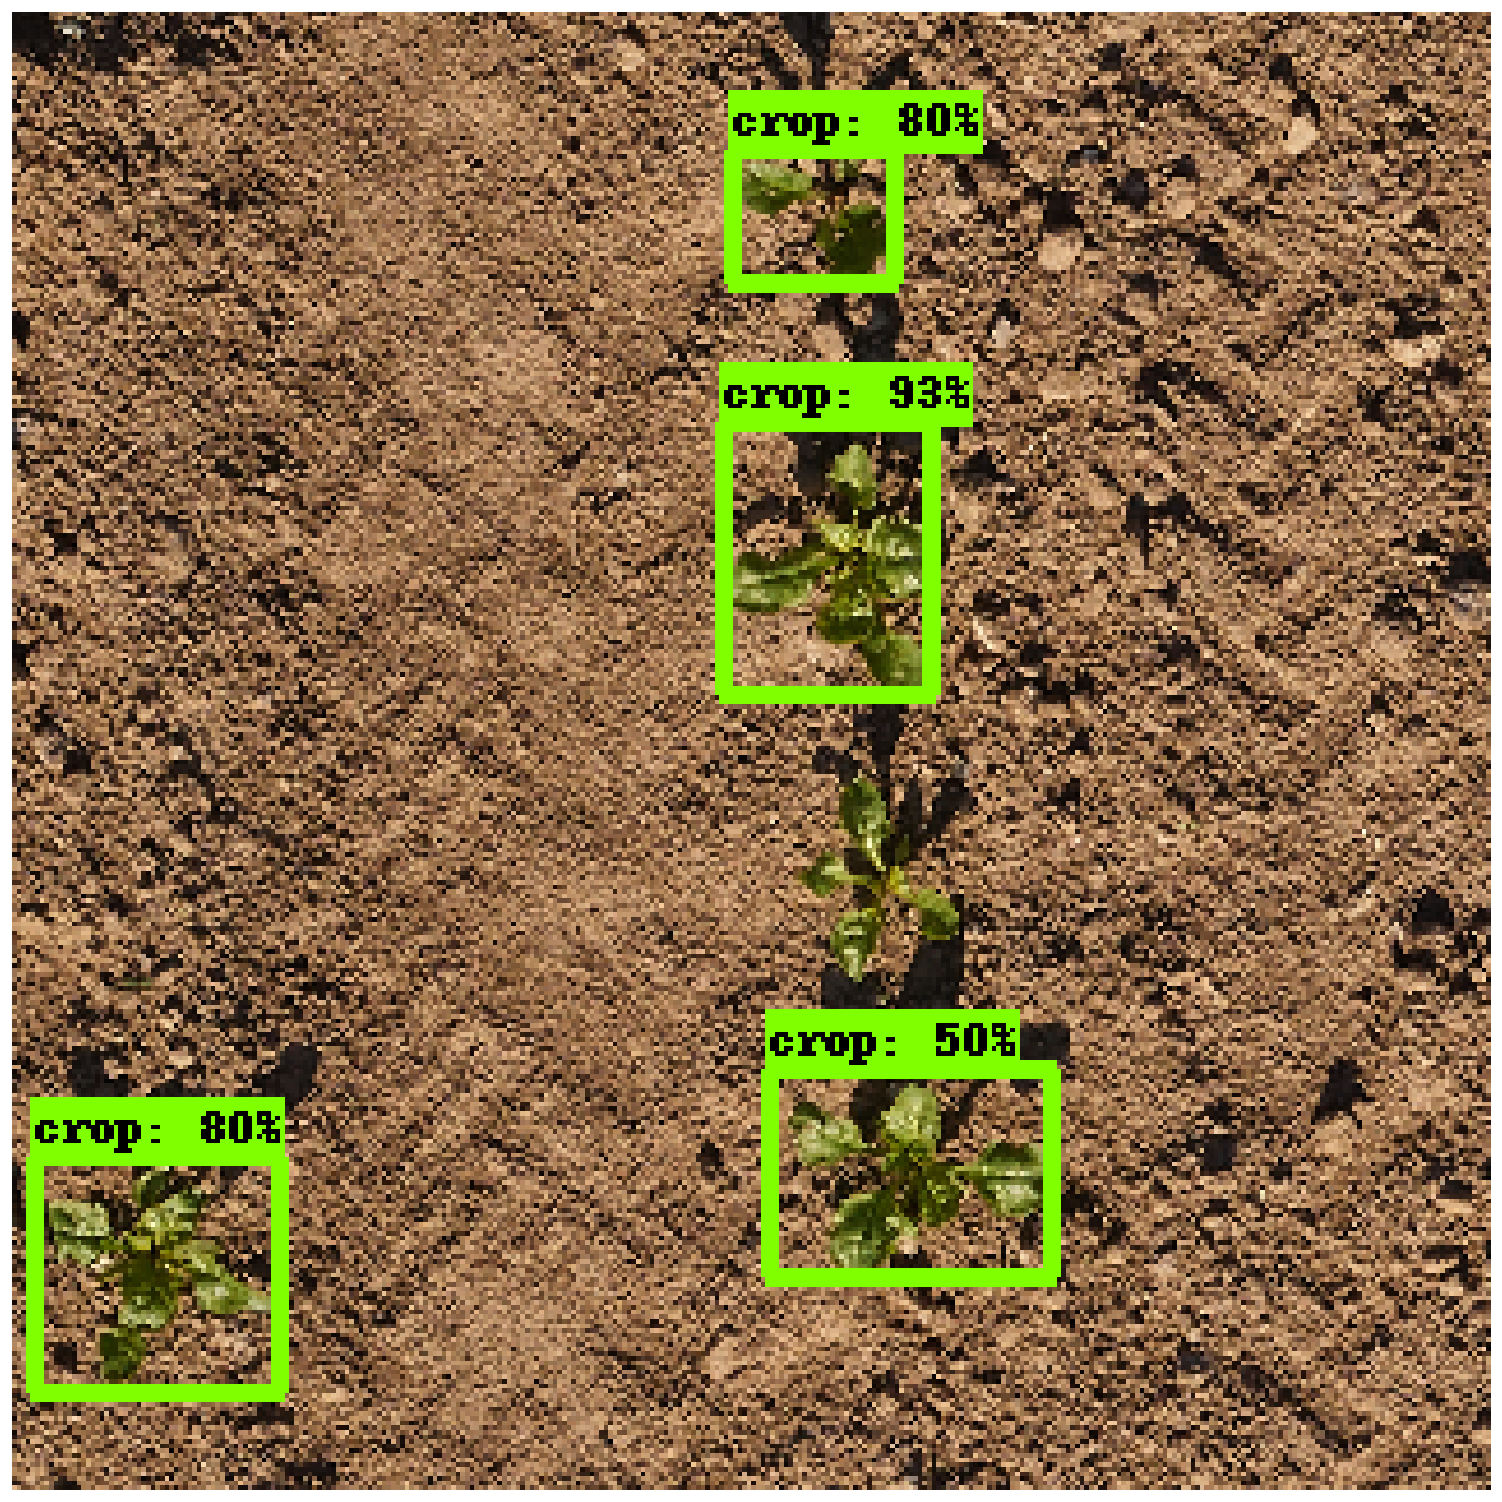

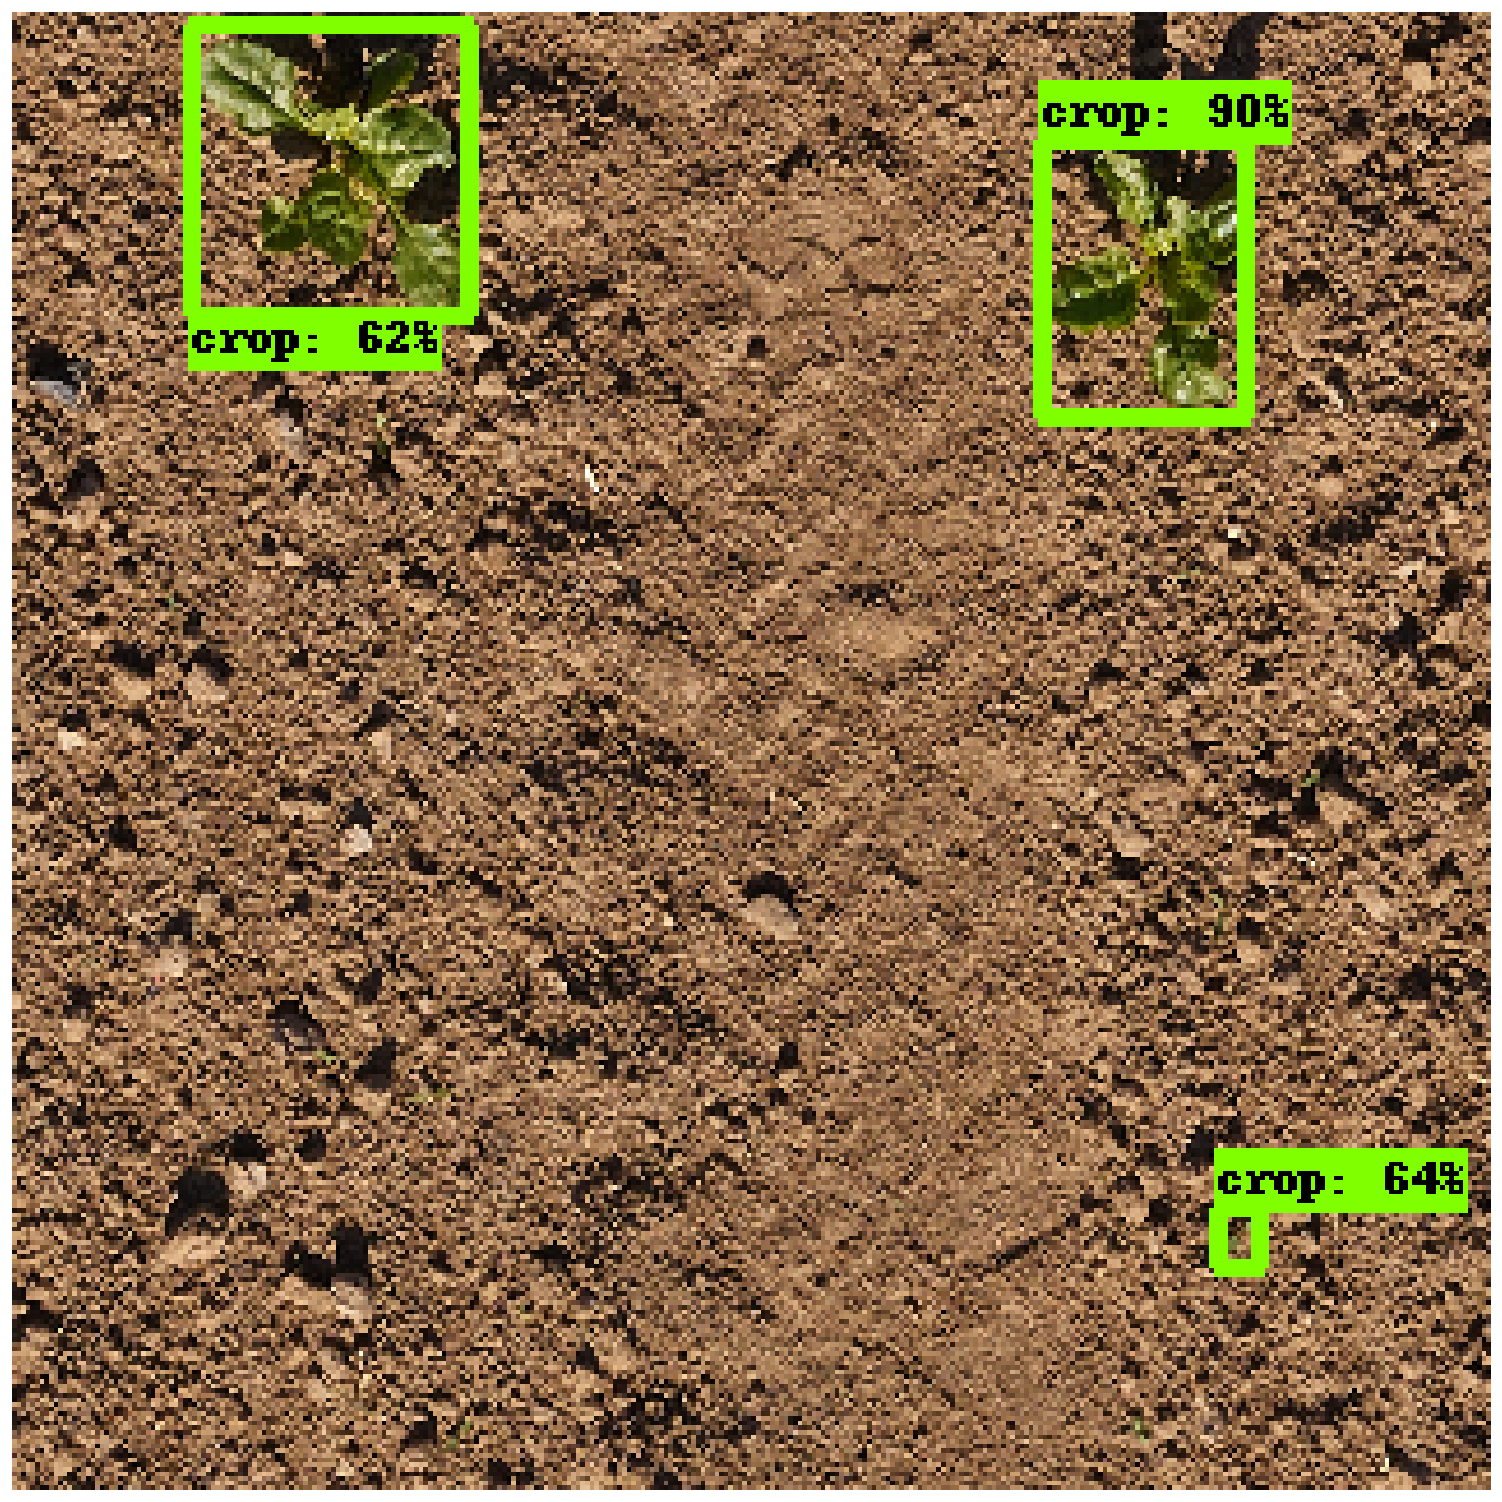

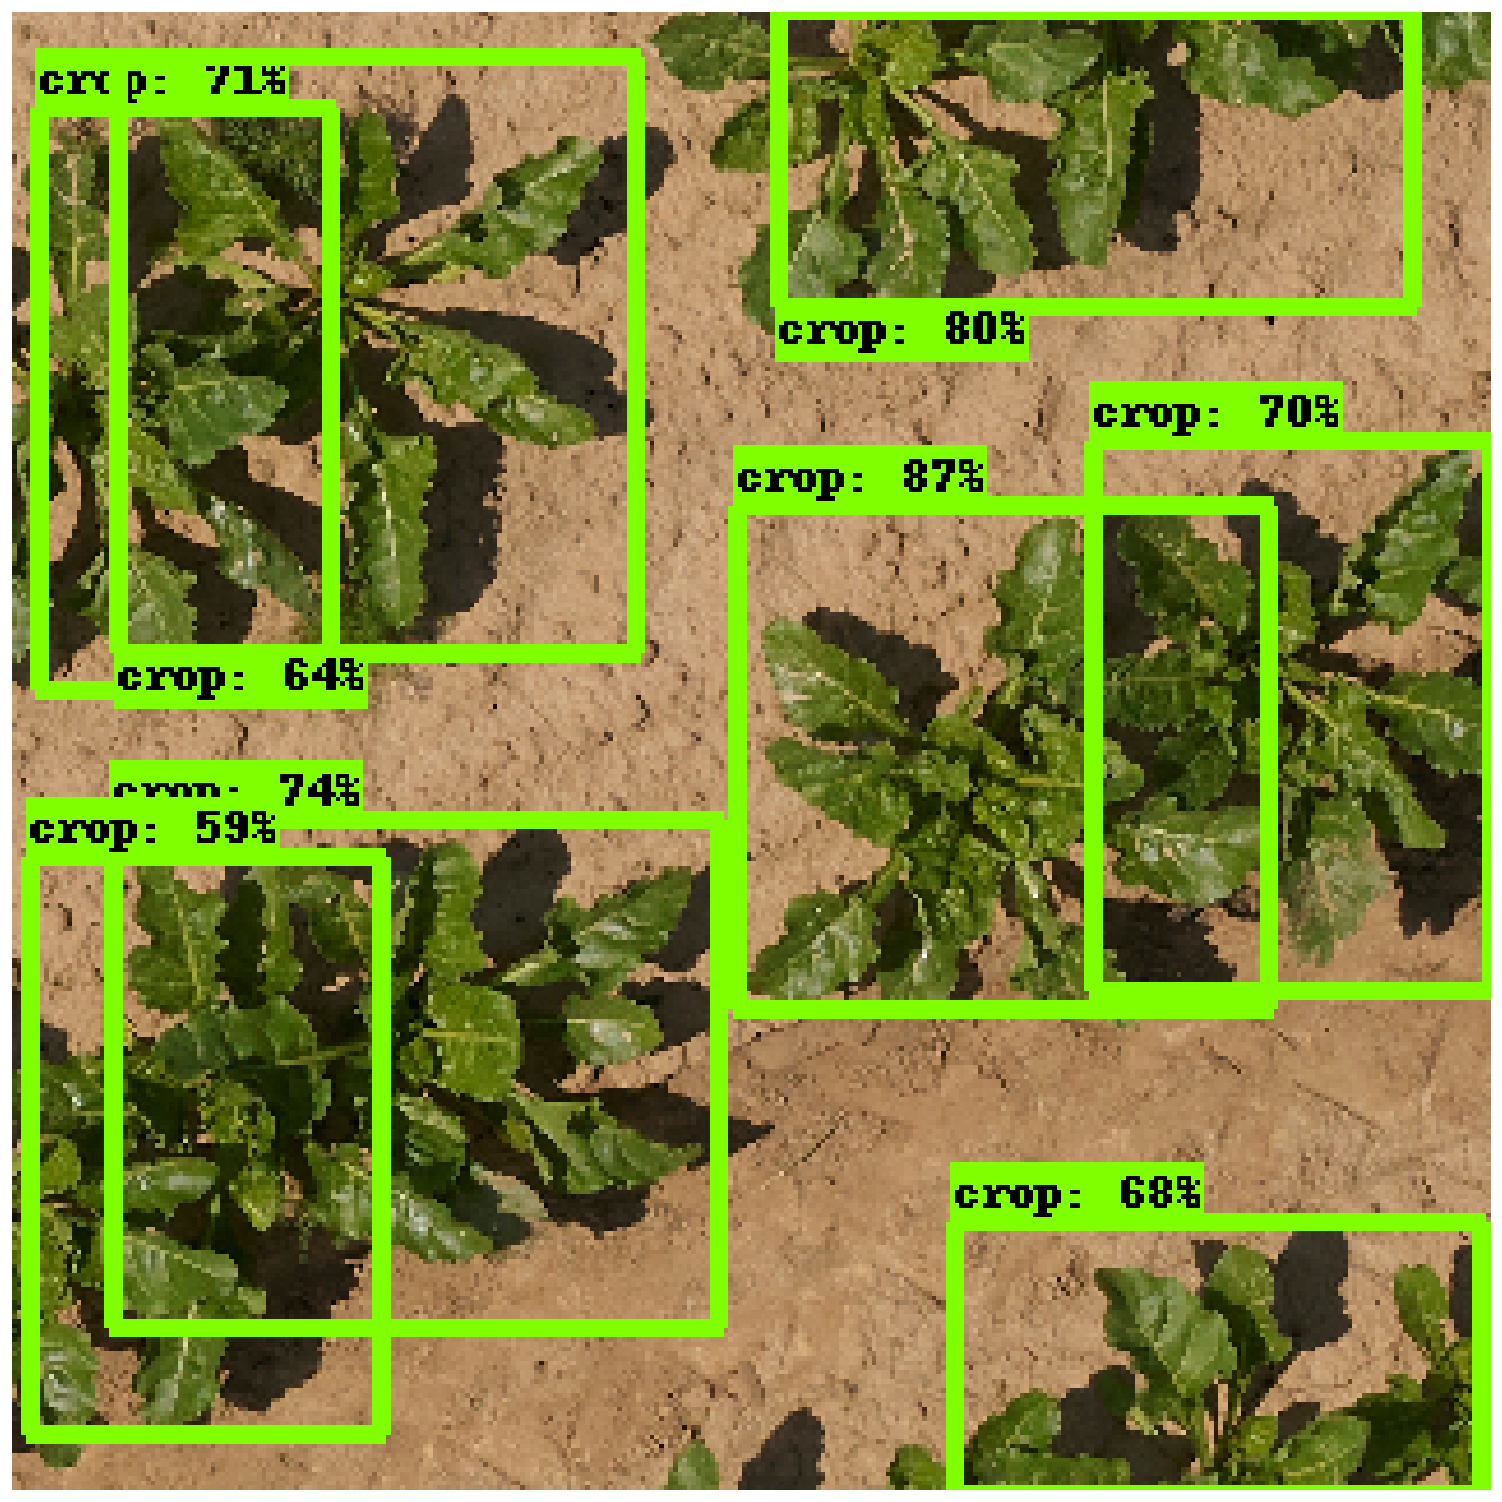

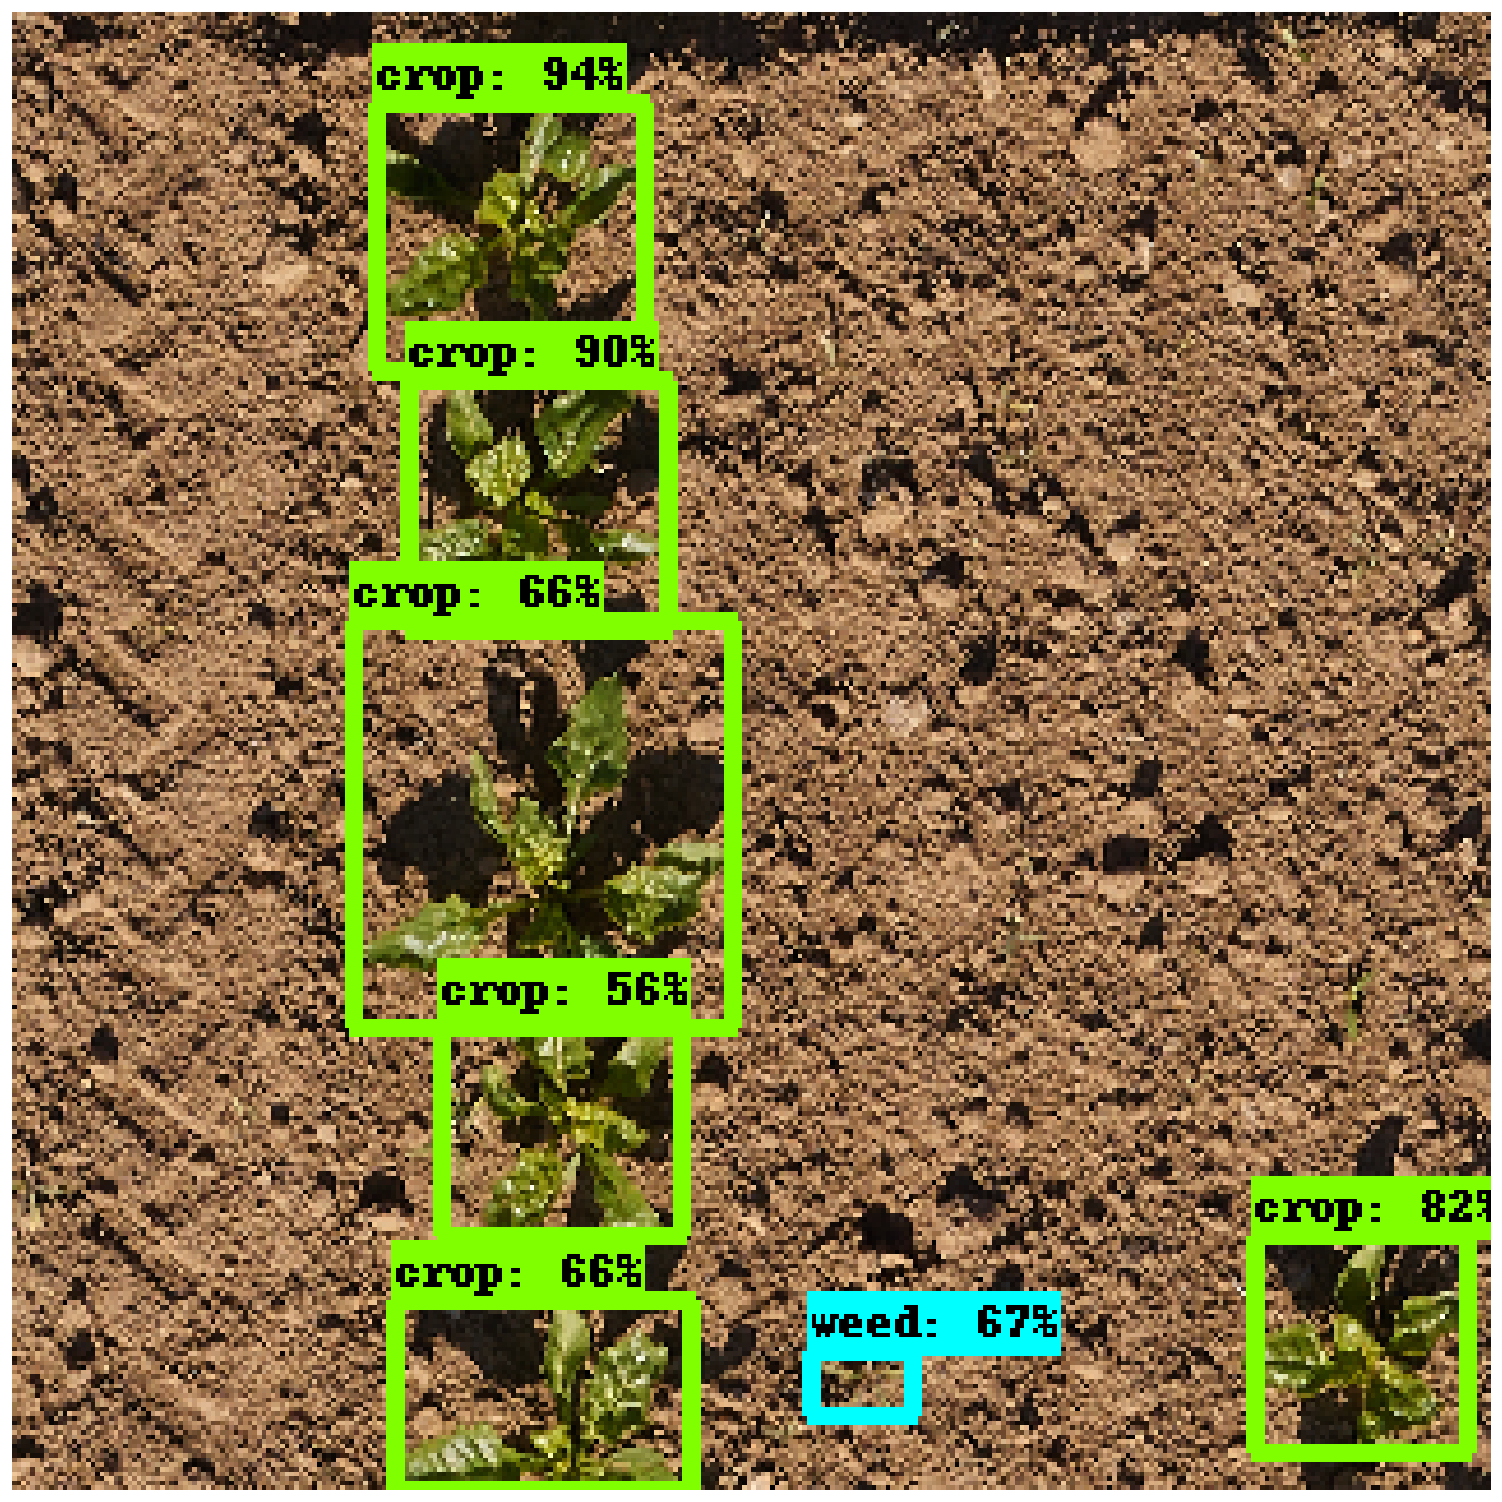

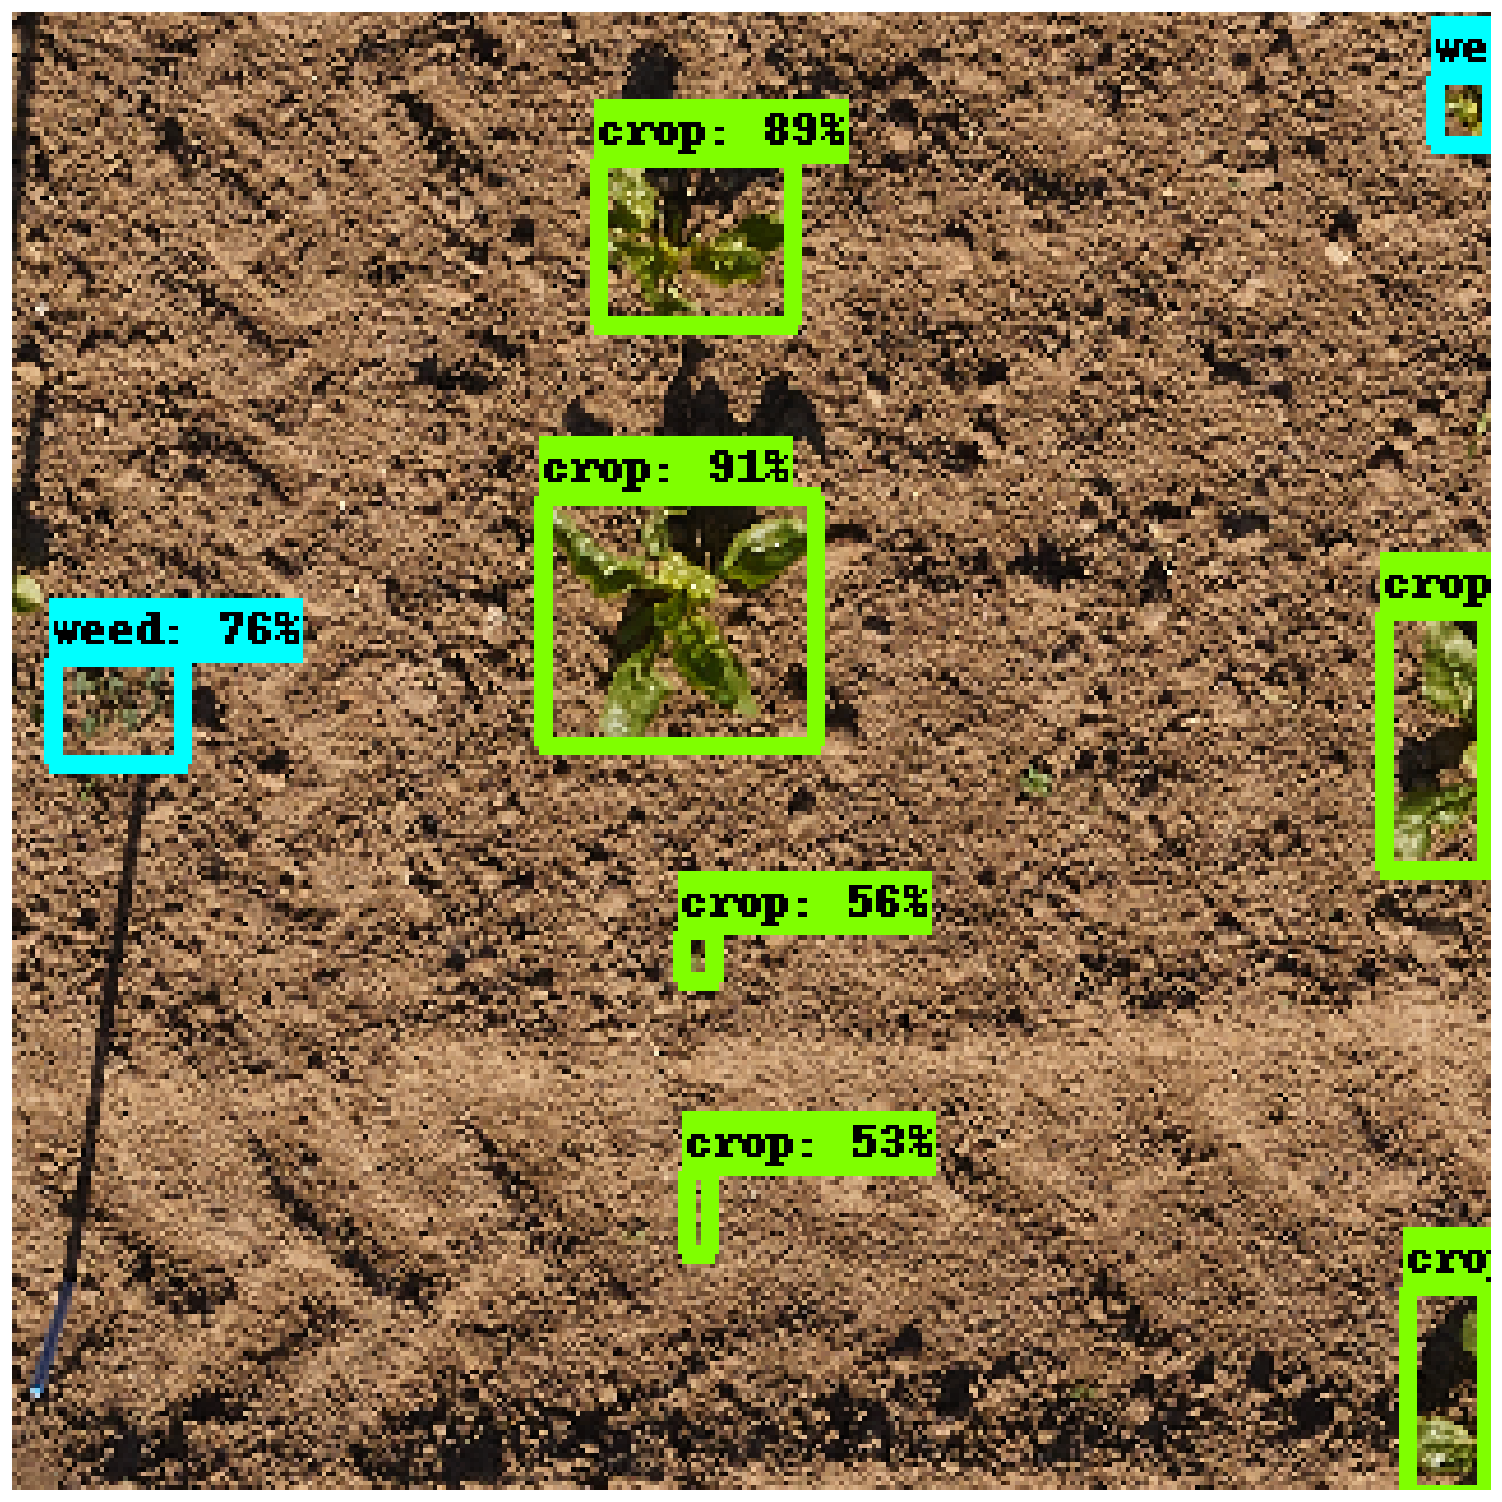

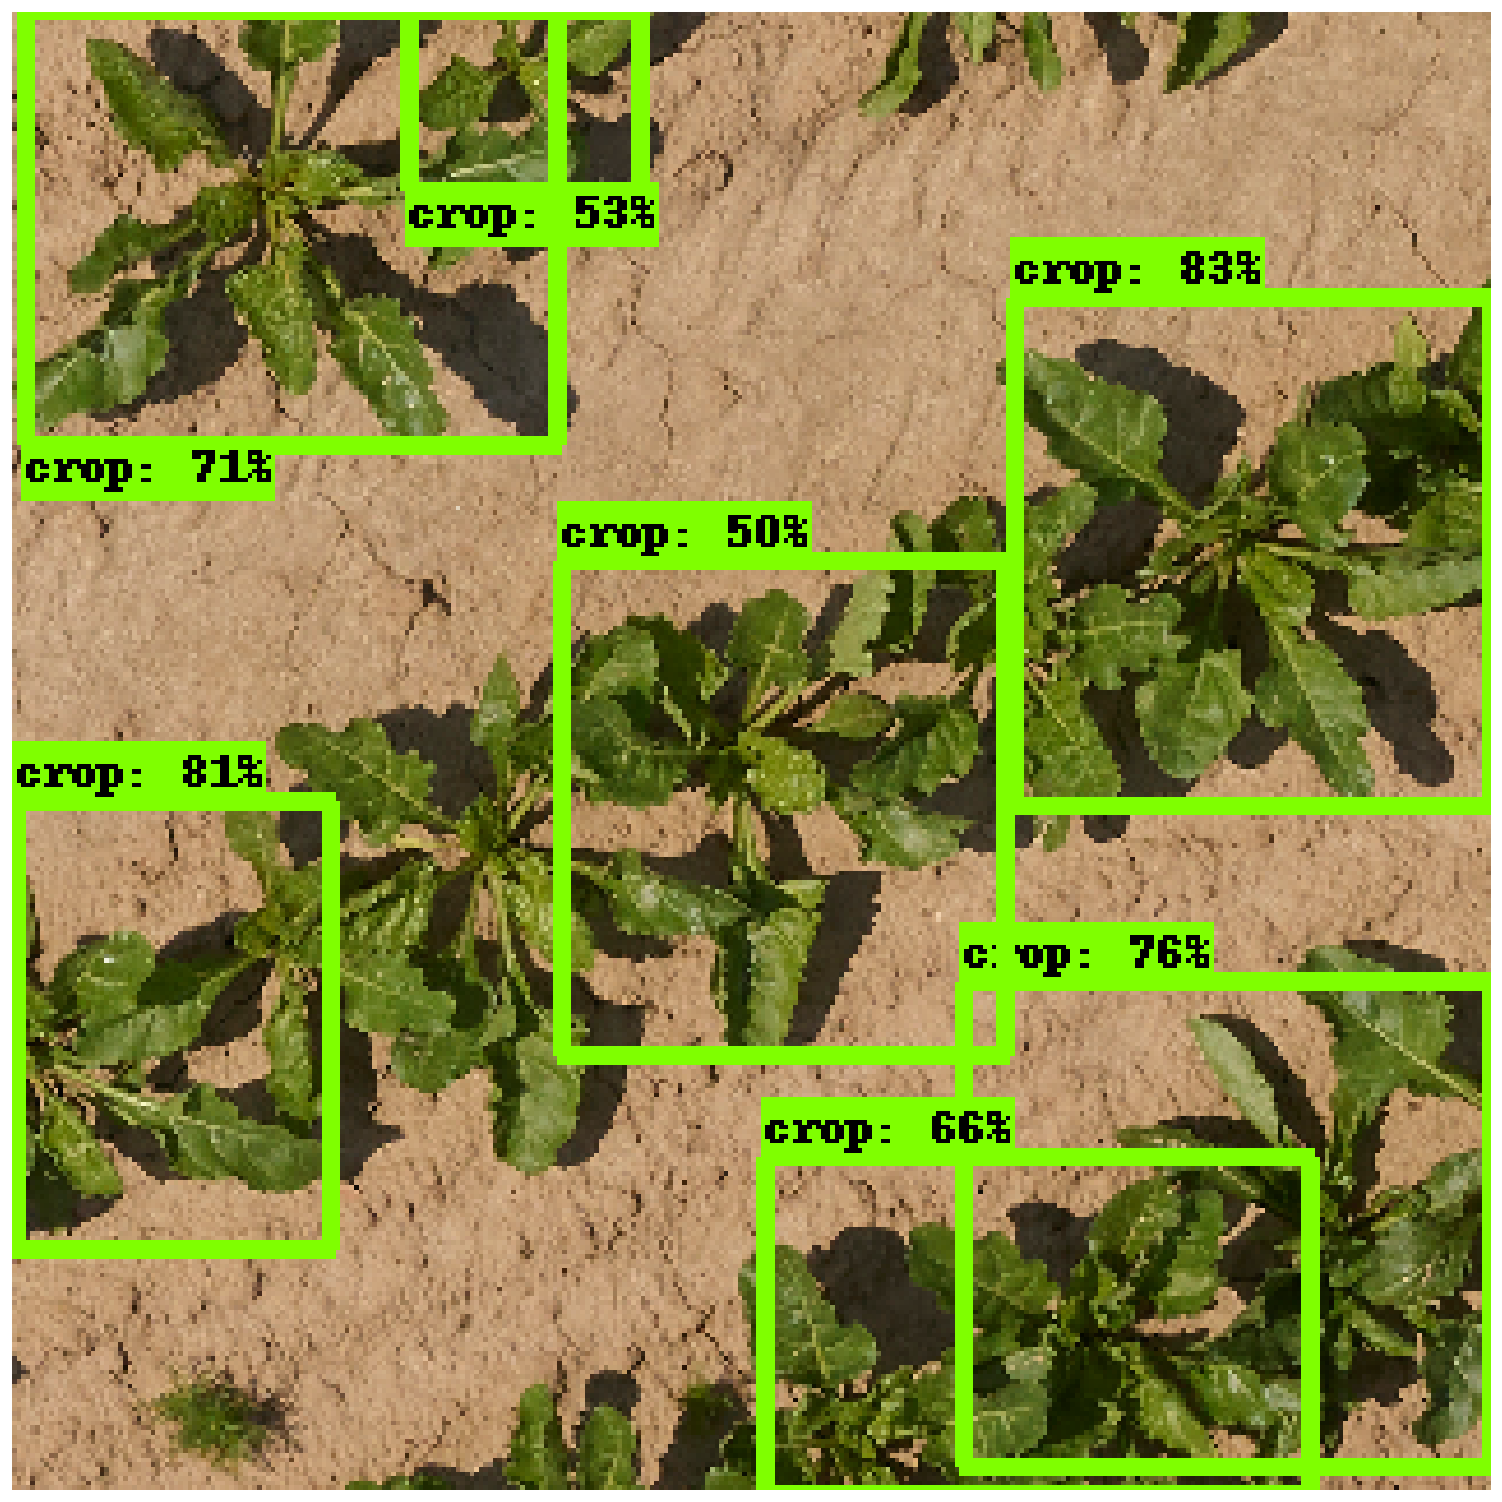

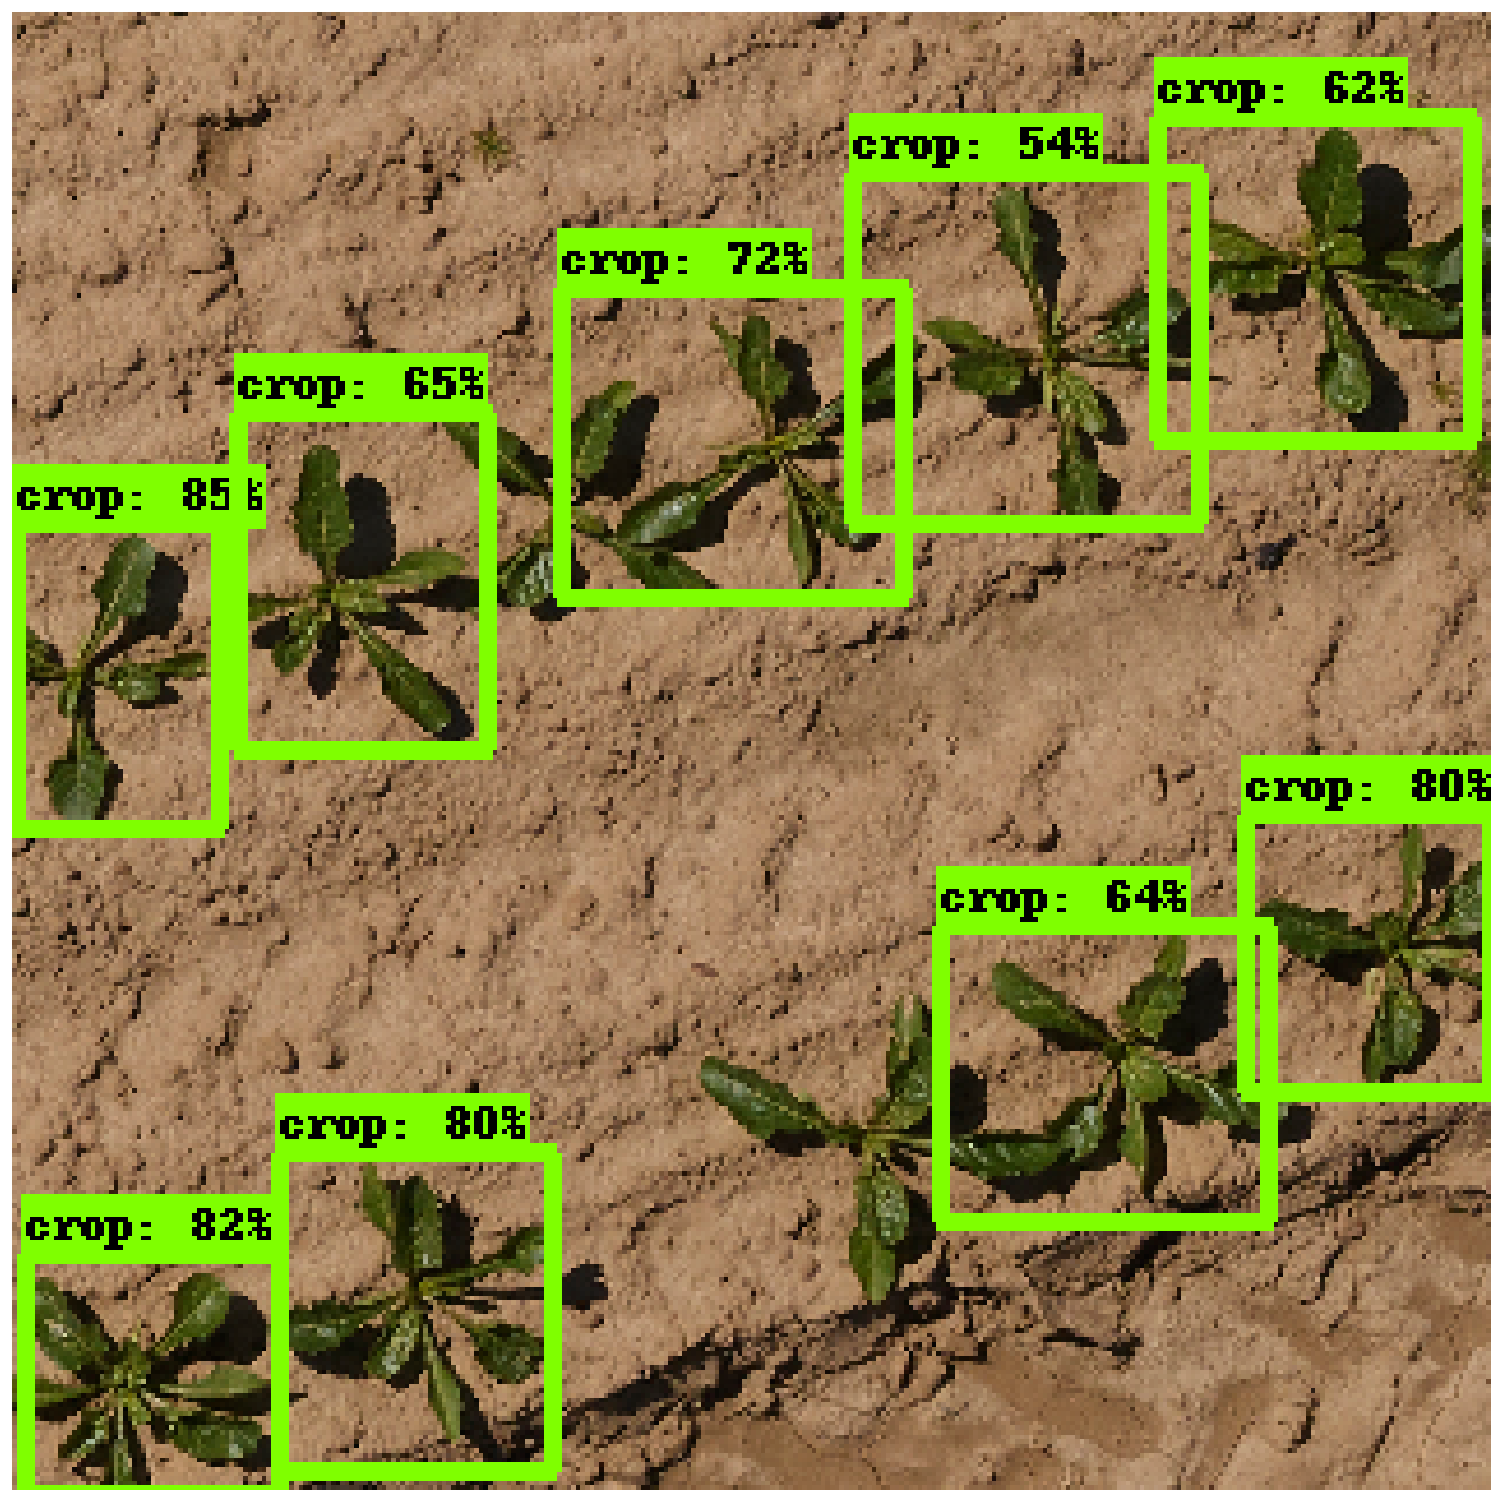

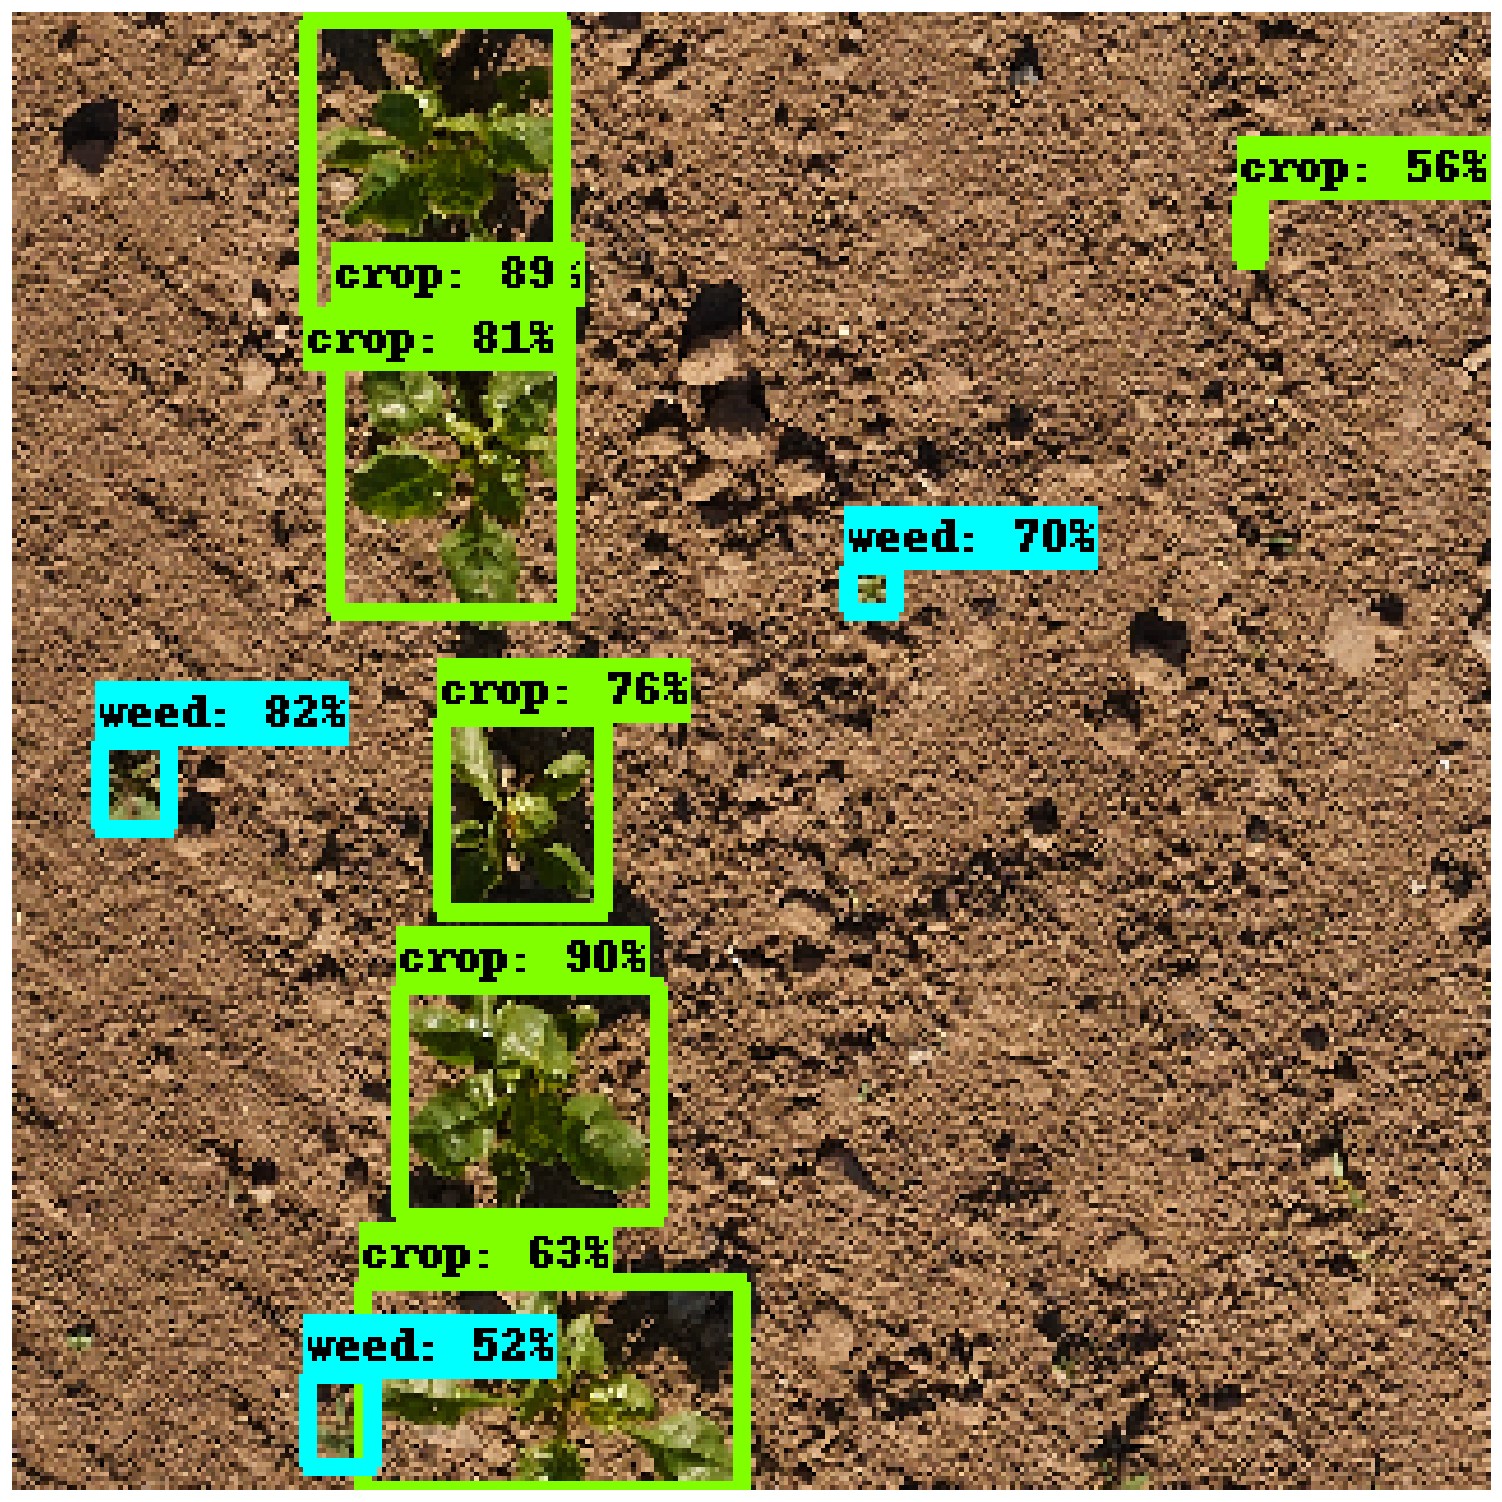

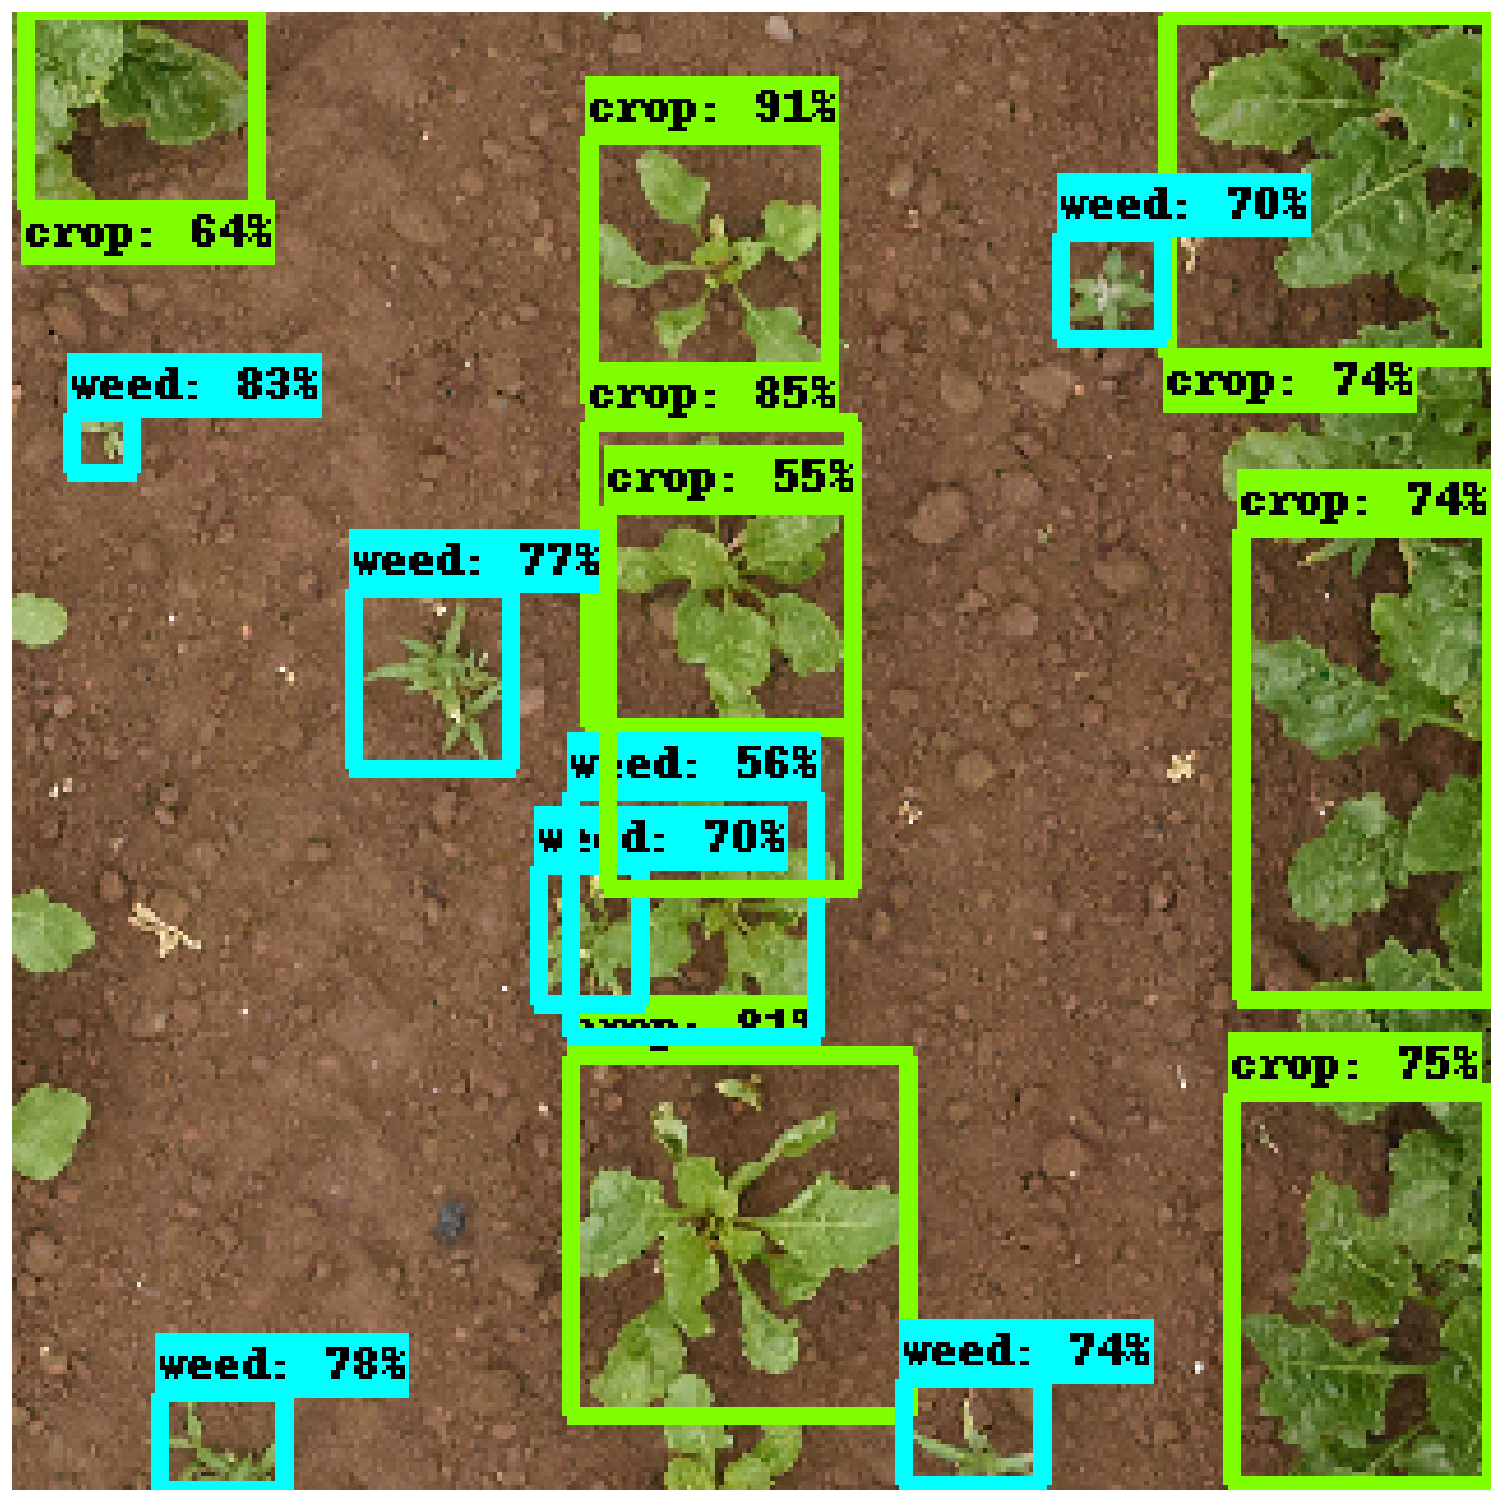

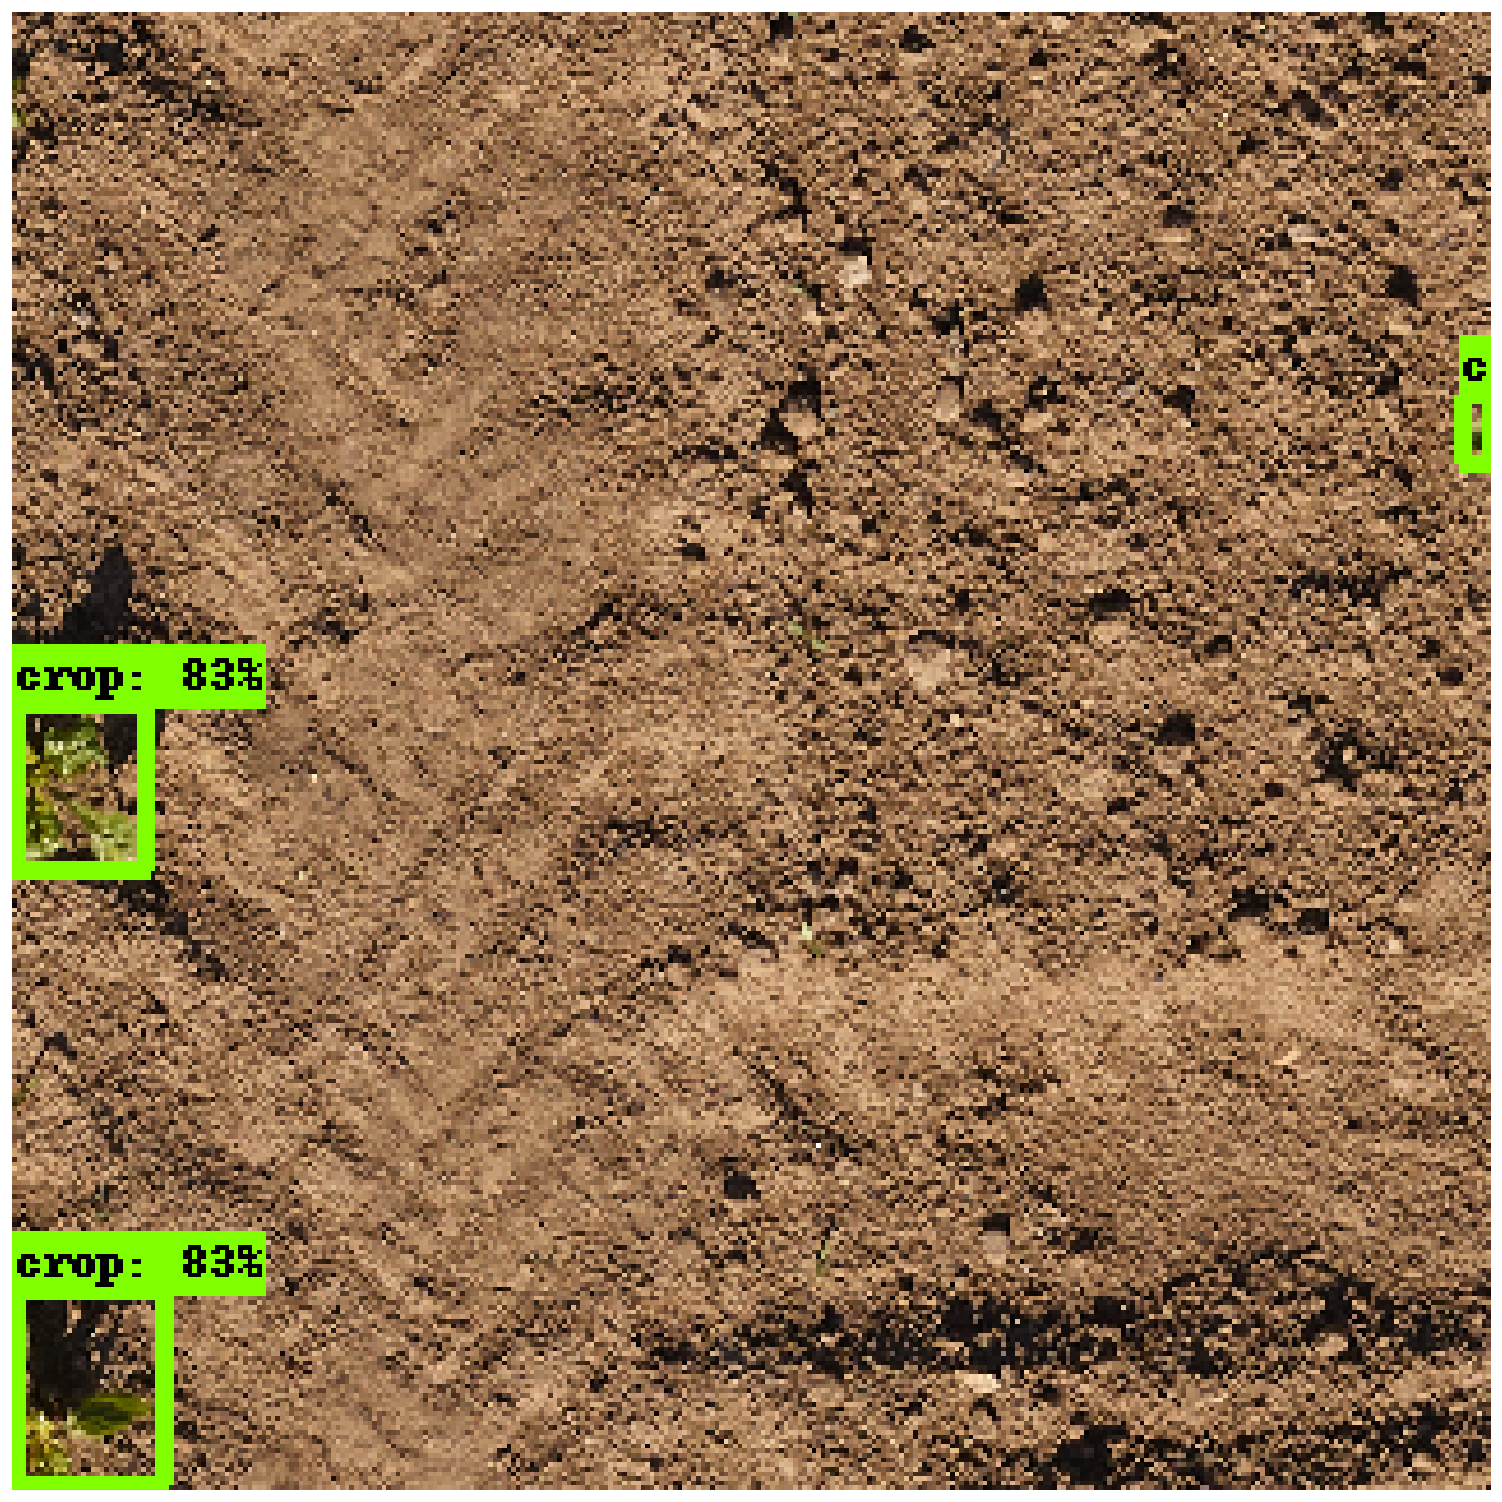

In [22]:
%matplotlib inline

from agri_vision_edge.tfod.inference import (
    load_saved_model,
    load_label_map,
    detect_image,
)

detect_fn = load_saved_model(str(PTQ_DIR / "saved_model"))
category_index = load_label_map(label_map_path)

for image_path in test_imgs[:10]:
    vis, _ = detect_image(
        detect_fn=detect_fn,
        image_path=image_path,
        category_index=category_index,
        image_size=config.image_size,
        score_threshold=0.5,
        max_boxes=60,
    )
    plt.figure(figsize=(16, 16))
    plt.imshow(vis)
    plt.axis("off")
    plt.show()
    plt.close()

## 12 · Discussion

`ptq` is the float base for post-training quantization: a reduced-schedule
finetune matching the QAT regime but without fake-quant. Compare its validation
mAP against the QAT notebooks once merged.

Next step — **INT8 TFLite conversion:** `notebooks/tflite_conversion.py`
calibrates this `ptq/` checkpoint to int8 (per-tensor and per-channel).